In [1]:
import pandas as pd
import numpy as np

This is for testing the baseline_model and to identify area for feature engineering

In [2]:
df1 = pd.read_csv("../data/materials_with_elasticity.csv")
y = df1["bulk_modulus_vrh"]
X = pd.read_csv("../data/materials_data.csv")

In [19]:
y.head()

0    16.491
1     9.808
2    28.202
3    12.624
4    33.938
Name: bulk_modulus_vrh, dtype: float64

In [21]:
pd.set_option('display.max_columns', None)
X.head()

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,MagpieData avg_dev NsUnfilled,MagpieData mode NsUnfilled,MagpieData minimum NpUnfilled,MagpieData maximum NpUnfilled,MagpieData range NpUnfilled,MagpieData mean NpUnfilled,MagpieData avg_dev NpUnfilled,MagpieData mode NpUnfilled,MagpieData minimum NdUnfilled,MagpieData maximum NdUnfilled,MagpieData range NdUnfilled,MagpieData mean NdUnfilled,MagpieData avg_dev NdUnfilled,MagpieData mode NdUnfilled,MagpieData minimum NfUnfilled,MagpieData maximum NfUnfilled,MagpieData range NfUnfilled,MagpieData mean NfUnfilled,MagpieData avg_dev NfUnfilled,MagpieData mode NfUnfilled,MagpieData minimum NUnfilled,MagpieData maximum NUnfilled,MagpieData range NUnfilled,MagpieData mean NUnfilled,MagpieData avg_dev NUnfilled,MagpieData mode NUnfilled,MagpieData minimum GSvolume_pa,MagpieData maximum GSvolume_pa,MagpieData range GSvolume_pa,MagpieData mean GSvolume_pa,MagpieData avg_dev GSvolume_pa,MagpieData mode GSvolume_pa,MagpieData minimum GSbandgap,MagpieData maximum GSbandgap,MagpieData range GSbandgap,MagpieData mean GSbandgap,MagpieData avg_dev GSbandgap,MagpieData mode GSbandgap,MagpieData minimum GSmagmom,MagpieData maximum GSmagmom,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,8.0,75.0,67.0,20.545455,19.801653,8.0,54.0,87.0,33.0,79.272727,11.239669,87.0,15.999400,186.207000,170.207600,47.701291,50.365712,15.9994,54.80,3459.00,3404.20,752.672727,1015.087603,54.80,2.0,16.0,14.0,13.090909,4.231405,16.

In [3]:
X.isnull().sum()

MagpieData minimum Number              0
MagpieData maximum Number              0
MagpieData range Number                0
MagpieData mean Number                 0
MagpieData avg_dev Number              0
                                      ..
MagpieData maximum SpaceGroupNumber    0
MagpieData range SpaceGroupNumber      0
MagpieData mean SpaceGroupNumber       0
MagpieData avg_dev SpaceGroupNumber    0
MagpieData mode SpaceGroupNumber       0
Length: 132, dtype: int64

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 132 entries, MagpieData minimum Number to MagpieData mode SpaceGroupNumber
dtypes: float64(132)
memory usage: 5.0 MB


In [6]:
print(y.describe())

count    5000.000000
mean      106.617061
std        69.558712
min         0.098000
25%        52.619250
50%        90.494500
75%       149.657000
max       400.846000
Name: bulk_modulus_vrh, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
# pipeline creates a whole auto process
models = {
    # it outputs the mean of bulk modulus for comparison
    "1. Dummy Baseline (Mean)": Pipeline([
        ('model', DummyRegressor(strategy='mean'))
    ]),
    
    # Tier 2: Linear Baseline (Needs scaling)
    "2. Scaled Linear (Ridge)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    
    "3. Random Forest": Pipeline([
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    
    "4. Gradient Boosting (Hist)": Pipeline([
        ('model', HistGradientBoostingRegressor(learning_rate=0.1, random_state=42))
    ])
}

results = []
metrics = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']

for name, pipeline in models.items():
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring=metrics, n_jobs=-1)
    
    rmse = -cv_scores['test_neg_root_mean_squared_error'].mean()
    mae = -cv_scores['test_neg_mean_absolute_error'].mean()
    r2 = cv_scores['test_r2'].mean()
    
    results.append({
        'Model': name,
        'CV RMSE': round(rmse, 3),
        'CV MAE': round(mae, 3),
        'CV R²': round(r2, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


                      Model  CV RMSE  CV MAE   CV R²
   1. Dummy Baseline (Mean)   69.497  56.238 -0.0010
   2. Scaled Linear (Ridge)   32.070  21.176  0.7846
           3. Random Forest   19.279  11.772  0.9229
4. Gradient Boosting (Hist)   17.508  10.690  0.9362


In [14]:
best_pipeline = models["4. Gradient Boosting (Hist)"]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print("=== FINAL TEST SET PERFORMANCE ===")
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.3f} GPa")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.3f} GPa")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")

=== FINAL TEST SET PERFORMANCE ===
Test RMSE: 15.649 GPa
Test MAE:  9.970 GPa
Test R²:   0.9497


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

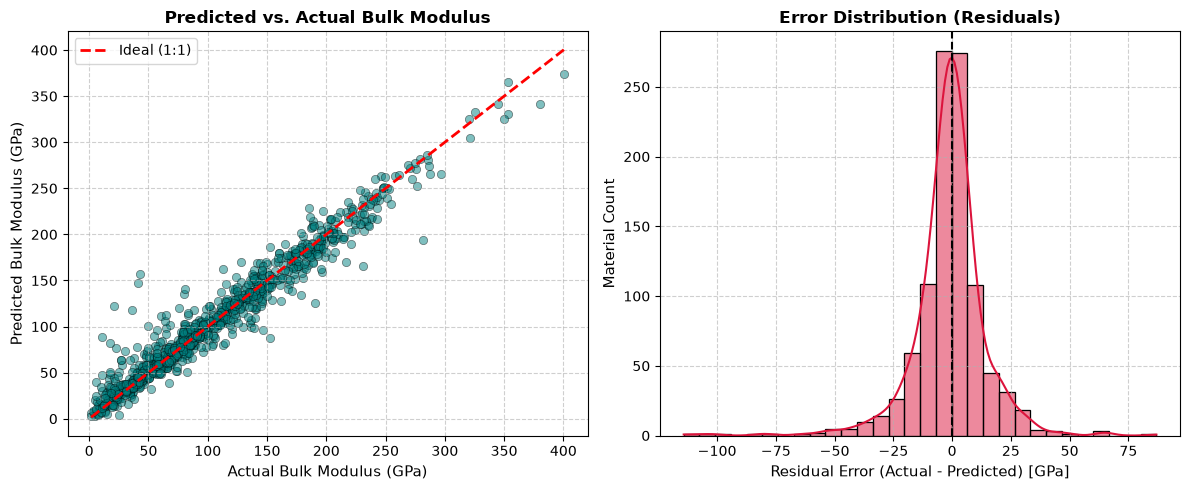


--- TOP 10 LARGEST PREDICTION FAILURES (HIGH RESIDUALS) ---
      Actual_Bulk_Modulus  Predicted_Bulk_Modulus  Absolute_Error_GPa  Residual_GPa
3501               42.606              156.804901          114.198901   -114.198901
1988               40.769              147.087438          106.318438   -106.318438
4525               21.309              122.033656          100.724656   -100.724656
1860              281.200              194.296278           86.903722     86.903722
2417               35.899              117.881289           81.982289    -81.982289
1075               11.036               88.766443           77.730443    -77.730443
1907              231.003              165.753755           65.249245     65.249245
3316               17.135               82.359444           65.224444    -65.224444
2602              152.126               87.456755           64.669245     64.669245
1018              190.453              125.846962           64.606038     64.606038


In [18]:

residuals = np.abs(y_test - y_pred)
error_df = pd.DataFrame({
    'Actual_Bulk_Modulus': y_test,
    'Predicted_Bulk_Modulus': y_pred,
    'Absolute_Error_GPa': residuals,
    'Residual_GPa': y_test - y_pred 
})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (1:1)')
plt.xlabel('Actual Bulk Modulus (GPa)', fontsize=11)
plt.ylabel('Predicted Bulk Modulus (GPa)', fontsize=11)
plt.title('Predicted vs. Actual Bulk Modulus', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.histplot(error_df['Residual_GPa'], kde=True, color='crimson', bins=30)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Residual Error (Actual - Predicted) [GPa]', fontsize=11)
plt.ylabel('Material Count', fontsize=11)
plt.title('Error Distribution (Residuals)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- TOP 10 LARGEST PREDICTION FAILURES (HIGH RESIDUALS) ---")
worst_errors = error_df.sort_values(by='Absolute_Error_GPa', ascending=False).head(10)
print(worst_errors.to_string())